In [4]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.featuresREB import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

In [5]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_25.csv')


train_df = pd.concat([s20,s21,s22,s23,s24])
val_df = s25
# test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
# print(f"Test data shape: {test_df.shape}")
# print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df

Training data shape: (123809, 954)
Training date range: 2019-10-22 to 2024-04-14
Validation data shape: (26306, 947)
Validation date range: 2024-10-22 to 2025-04-13


Unnamed: 0      PLAYER_NAME  PLAYER_ID    MATCHUP TEAM_ABBREVIATION  \
0               0         Alex Len     203458  ATL @ DET               ATL   
1               1   Bruno Fernando    1628981  ATL @ DET               ATL   
2               2      Cam Reddish    1629629  ATL @ DET               ATL   
3               3  De'Andre Hunter    1629631  ATL @ DET               ATL   
4               4  DeAndre' Bembry    1627761  ATL @ DET               ATL   
...           ...              ...        ...        ...               ...   
26396       26396      Leaky Black    1641778  CHA @ CLE               CHA   
26397       26397   Marques Bolden    1629716  CHA @ CLE               CHA   
26398       26398   Nick Smith Jr.    1641733  CHA @ CLE               CHA   
26399       26399         Tre Mann    1630544  CHA @ CLE               CHA   
26400       26400   Vasilije Micic     203995  CHA @ CLE               CHA   

          TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID   GAME_DATE WL  PTS  \
0      1610612737              DET          0  21900014  2019-10-24  W    4   
1      1610612737              DET          0  21900014  2019-10-24  W    7   
2      1610612737              DET          0  21900014  2019-10-24  W    1   
3      1610612737              DET          0  21900014  2019-10-24  W   14   
4      1610612737              DET          0  21900014  2019-10-24  W    8   
...           ...              ...        ...       ...         ... ..  ...   
26396  1610612766              CLE          0  22301187  2024-04-14  W   11   
26397  1610612766              CLE          0  22301187  2024-04-14  W   14   
26398  1610612766              CLE          0  22301187  2024-04-14  W   24   
26399  1610612766              CLE          0  22301187  2024-04-14  W   11   
26400  1610612766              CLE          0  22301187  2024-04-14  W    3   

       AST  REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  FTM  FTA  FT_PCT  \
0        1    6    1    5   0.200     0     2    0.000    2    2     1.0   
1        2    3    3    6   0.500     1     1    1.000    0    0     NaN   
2        1    7    0    6   0.000     0     5    0.000    1    2     0.5   
3        0    2    5    8   0.625     2     3    0.667    2    2     1.0   
4        3    2    4    5   0.800     0     1    0.000    0    0     NaN   
...    ...  ...  ...  ...     ...   ...   ...      ...  ...  ...     ...   
26396    5    6    4    4   1.000     2     2    1.000    1    1     1.0   
26397    2    8    7   10   0.700     0     1    0.000    0    0     NaN   
26398    3    6    9   20   0.450     6    11    0.545    0    0     NaN   
26399    6    4    4   11   0.364     3     6    0.500    0    0     NaN   
26400    4    1    1    4   0.250     1     3    0.333    0    0     NaN   

       OREB  DREB  STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  POINT_PER_SHOT  \
0         2     4    2    1    1          -1         20.7           0.680   
1         1     2    0    0    0           7         13.6           1.167   
2         1     6    1    0    0          11         13.9           0.145   
3         0     2    0    0    2           9         14.4           1.577   
4         1     1    2    0    0          11         20.9           1.600   
...     ...   ...  ...  ...  ...         ...          ...             ...   
26396     0     6    2    1    0          22         34.7           2.477   
26397     4     4    1    4    1           5         40.6           1.400   
26398     1     5    1    0    1           9         37.7           1.200   
26399     0     4    1    0    2          -3         25.8           1.000   
26400     0     1    0    0    1          -8          9.2           0.750   

            EFG START_POSITION  COMMENT  OFF_RATING  E_OFF_RATING  DEF_RATING  \
0      0.200000              C      NaN        86.5          86.5        88.0   
1      0.583333            NaN      NaN       150.0         150.0       129.6   
2      0.000000              G      NaN 

In [6]:
newFeatures = val_df.columns[val_df.columns.tolist().index('STARTING'):].tolist()
df_subset = val_df[newFeatures]

In [7]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

def select_features_xgb_importance(X, y, top_n=150):
    xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb.fit(X, y)
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_features = importance_df.head(top_n)['feature'].tolist()
    return X[top_features], top_features

# Select top 300 features from your newFeatures array
selected_features, top_features = select_features_xgb_importance(
    train_df[newFeatures], 
    train_df['REB'], 
    top_n=60
)
top_features = [f for f in top_features]
# Apply the same feature selection to your other datasets
# test_df_selected = test_df[top_features]
val_df_selected = val_df[top_features]

# Get the selected training data
train_df_selected = train_df[top_features]

print(f"Selected {len(top_features)} features from your newFeatures array")
print(f"Top 10 most important features:")
for i, feature in enumerate(top_features[:10]):
    print(f"{i+1}. {feature}")

Selected 60 features from your newFeatures array
Top 10 most important features:
1. REB_ROLLING_AVG_15
2. REB_ROLLING_AVG_40
3. REB_ROLLING_AVG_25
4. RBC_ROLLING_AVG_15
5. REB_ROLLING_AVG_10
6. RBC_ROLLING_AVG_5
7. RBC_ROLLING_AVG_10
8. RBC_ROLLING_AVG_7
9. REB_AVG_TO_DATE
10. REB_WITHOUT_STAR


In [8]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=top_features,
    target_col="REB",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False,
    tune_hyperparams=False,
    tune_iters=100
)

print("Validation metrics:", val_metrics)

# test_metrics, residuals_df = evaluate_test(xgbModel, test_df, top_features, "REB", used_cats)
# print("Test metrics:", test_metrics)


Validation metrics: {'RMSE': 2.3909251970279697, 'MAE': 1.8197712989793497, 'R2': 0.5244125723838806, 'best_iteration': 412}


In [9]:
joblib.dump(xgbModel, 'Models/xgbREBModel.pkl')
joblib.dump(top_features, 'Models/topREBfeatures.pkl')

['Models/topREBfeatures.pkl']

In [10]:
feature_importance = pd.DataFrame({
    'feature': top_features,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                 TOP_FEATURES  TOP_IMPORTANCE                          BOTTOM_FEATURES  BOTTOM_IMPORTANCE
           REB_ROLLING_AVG_15        0.224307                       GAMES_WITHOUT_STAR           0.002781
           REB_ROLLING_AVG_25        0.209949                      DRBC_ROLLING_AVG_10           0.002765
           REB_ROLLING_AVG_40        0.096378                         POSS_AVG_TO_DATE           0.002753
           RBC_ROLLING_AVG_10        0.062438                      DIST_ROLLING_AVG_25           0.002742
                     STARTING        0.062165                FANTASY_PTS_ROLLING_AVG_5           0.002648
           REB_ROLLING_AVG_10        0.045500                  DREB_PCT_ROLLING_AVG_25           0.002608
           RBC_ROLLING_AVG_15        0.025822                                RBC_LAG_1           0.002594
             REB_WITHOUT_STAR        0.025808           MATCHUP_AVG_REB_LAST_3_TO_DATE           0.002573
PL

In [9]:
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,TEAM_STAR_OUT,HOME_GAME,MIN
0,0,13.331424,13.331424,Domantas Sabonis,SAC @ HOU,113,103.0,1,0,0,1.27
1,0,13.061146,13.061146,Jarrett Allen,CLE vs. IND,118,126.0,1,0,1,0.68
2,2,14.433641,12.433641,Alperen Sengun,HOU vs. OKC,125,111.0,1,0,1,33.83
3,2,12.852017,10.852017,Anthony Davis,LAL @ PHI,104,118.0,1,0,0,9.83
4,5,15.596070,10.596070,Alperen Sengun,HOU @ SAS,106,109.0,1,0,0,22.05
5,1,10.946237,9.946237,Domantas Sabonis,SAC vs. MEM,132,122.0,1,0,1,12.07
6,1,10.748821,9.748821,Chet Holmgren,OKC @ POR,137,114.0,1,1,0,18.38
7,1,10.700342,9.700342,Jalen Duren,DET @ MIL,133,140.0,1,0,0,8.35
8,0,9.521464,9.521464,Jalen Duren,DET vs. PHI,96,111.0,1,0,1,12.53
9,2,11.056724,9.056724,Nikola Jokić,DEN vs. PHX,117,90.0,1,0,1,29.75


C:\Users\alexg\AppData\Local\Temp\ipykernel_25840\2114919491.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_25840\2114919491.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


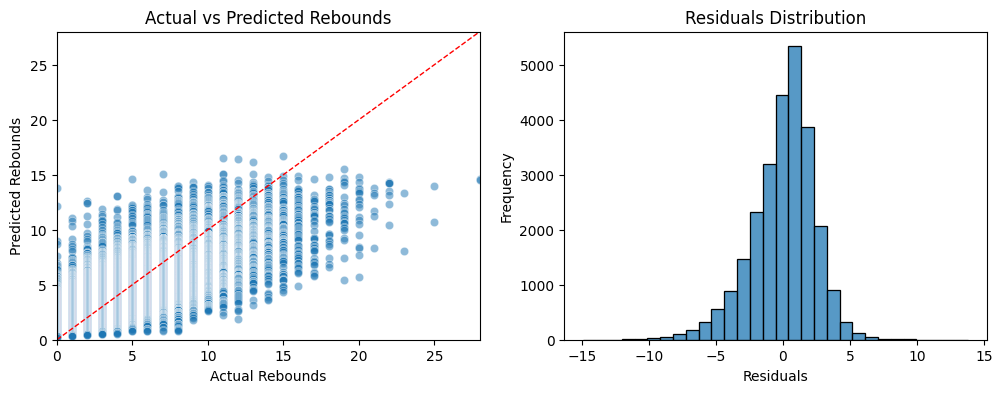

In [15]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Rebounds')
axes[0].set_xlabel('Actual Rebounds')
axes[0].set_ylabel('Predicted Rebounds')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()